# Processing disentanglement data

## Imports and setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd
import os
sys.path.append("/home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/scripts")
import spotfinderB as spotB
#plt.style.use("/Users/sean/.config/matplotlib/matplotlibrc")
data_dir = "/home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/"
figure_dir = "/home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/figures"

In [2]:
xDir = "xScan"
xRange = np.arange(0,21,step=5).astype(str)

yDir = "yScan"
yRange = np.arange(0,21,step=5).astype(str)

Pseudocode for the data processing
```
# For each scan directory
    # Instantiate data storage object for entire scan directory
    # Iterate over each sub directory (numbers)
        # Instantiate data storage object for scan position
        # grab only .tif files in sub directory
        # For each .tif file
            # Run Spotfinder with optimal parameters
            # Store data in sub-directory data object
        # Store data for the scan directory
    # Save data product for the scan directory
```

## Process the data

In [94]:
names = ['peaks',"x","y","fwhm","energy","radius",
         'peaks_std',"x_std","y_std","fwhm_std","energy_std","radius_std",
         "stage_pos"]
formats = ['f8','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8',"i4"]
nm_fm = []
for n,f in zip(names,formats):
    nm_fm.append((n,f))

In [ ]:
%%time
verbose=False
# for directory,ranges in zip([xDir,yDir],[xRange,yRange]):
for directory,ranges in zip([xDir],[xRange]):
    scanDir = os.path.join(data_dir,directory)
    print(f"Scanning {scanDir}")
    
    scanResult = np.array([],dtype=nm_fm)

    for p in ranges:
        subDir = os.path.join(scanDir,p)
        print(f"Scanning {subDir}")
        tifFiles = np.array(os.listdir(subDir))[np.array([x.endswith(".tif") for x in os.listdir(subDir)])]
        print(f"Found {len(tifFiles)} tif files in {subDir}")
        subDir_nm_fm = nm_fm[0:6]
        subDirCents = np.array([])
        for f in tifFiles:
            finder = spotB.SpotFinder(file_path=os.path.join(subDir,f),max_counts=4000,min_energy=25,fboxsize=150,gaussian=True,gaussian_sig=4,li=True)
            centroid = finder.get_centroids()
            centroid['radius'] = centroid['fwhm']/(2*np.sqrt(2*np.log(2)))
            for k,v in zip(centroid.keys(),centroid.values()):
                centroid[k] = v[0]
            subDirCents = np.append(subDirCents,centroid)
        vals = [tuple(x.values()) for x in subDirCents]
        centroidResult = np.array(vals,dtype=subDir_nm_fm)

        thisRange = []

        for n in centroidResult.dtype.names:
            median = np.median(centroidResult[n])
            thisRange.append(median)
            
        for n in centroidResult.dtype.names:
            std = np.std(centroidResult[n])
            thisRange.append(std)

        thisRange.append(int(p))

        scanResult = np.append(scanResult, np.array(tuple(thisRange),dtype=nm_fm))

        print(f"Results for {subDir} are stored in memory.")

    # Save the result
    saveFile = f"{directory}_results_2"
    np.save(os.path.join(data_dir,saveFile),scanResult)

    print(f"Results for {scanDir} were saved to {os.path.join(data_dir,saveFile)}.npy.")
    

Scanning /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan
Scanning /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/0
Found 5 tif files in /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/0


/home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/scripts/spotfinderB.py:44: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, _ = optimize.leastsq(errorfunction, params)


Results for /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/0 are stored in memory.
Scanning /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/5
Found 5 tif files in /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/5
Results for /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/5 are stored in memory.
Scanning /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/10
Found 5 tif files in /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/10
Results for /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/10 are stored in memory.
Scanning /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/15
Found 5 tif files in /home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan/15
Results for /home/pos-control/Andrin/LAB-positioner-tilt

In [11]:
import numpy as np

# Load the data
data = np.load("/home/pos-control/Andrin/LAB-positioner-tilt/TiltTest/data/metrologyScan25/xScan_results_2.npy")
import pandas as pd

df = pd.DataFrame(data)
print(df.head()) # Shows the first 5 rows with column names as headers

           peaks            x            y          fwhm         energy  \
0  117149.891563  2172.869502  1537.524829  21304.194894  623946.030431   
1     215.964551  2146.316539  1538.300992    884.805850      47.771674   
2     433.061391  2115.160755  1543.336736   1198.931355     129.802720   
3  157723.421248  2089.396033  1544.078578  23238.727335  916322.895196   
4      65.461170  2063.976318  1538.226901    431.445474       7.060731   

        radius     peaks_std     x_std     y_std     fwhm_std     energy_std  \
0  9047.058581  13375.928666  0.255104  0.253182  1239.547932  108820.906392   
1   375.742449     24.865515  0.198580  0.180027    52.595434       8.517487   
2   509.139269    106.329526  0.219015  0.241687   147.971723      49.664050   
3  9868.578868  14813.684830  0.076448  0.231670  1051.704482  135416.212417   
4   183.218023      0.918714  0.106066  0.074549     4.743150       0.174485   

   radius_std  stage_pos  
0  526.387541          0  
1   22.335224 

## Make some plots

In [96]:
resultFiles = np.array(os.listdir(data_dir))[np.array([x.endswith(".npy") for x in os.listdir(data_dir)])]
resultFiles

array(['xScan_results_2.npy'], dtype='<U19')

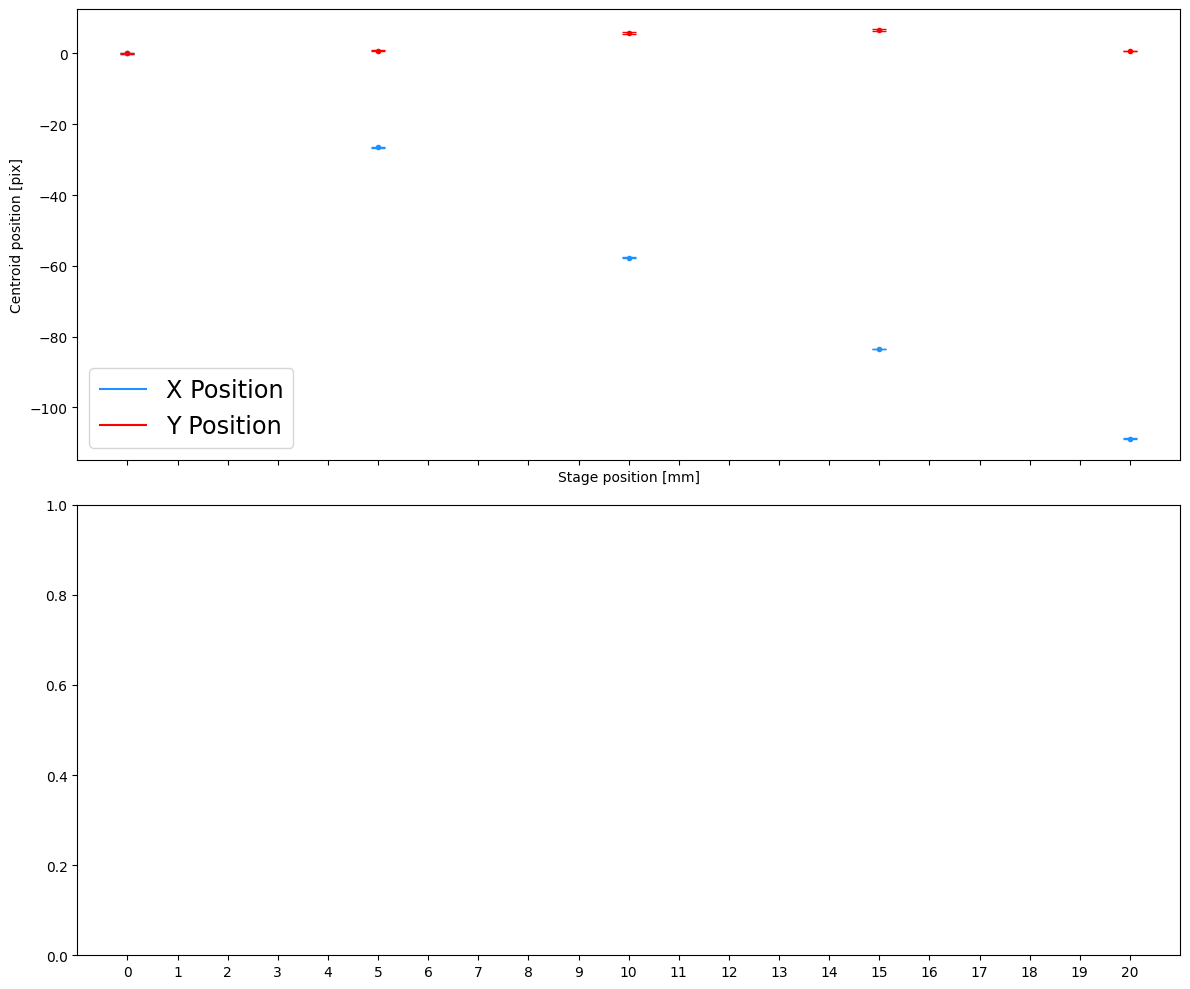

In [97]:
fig,axs = plt.subplots(nrows=2,figsize=[12,10],sharex=True)

outDir = os.path.join(data_dir,"results")

os.makedirs(outDir,exist_ok=True)

for file,ax,maskVal in zip(resultFiles,axs.flatten(),[None,None]):

    result = np.load(os.path.join(data_dir,file))
    useResult = result[result['stage_pos']!=maskVal]
    
    l1 = ax.errorbar(useResult['stage_pos'],useResult['x']-useResult['x'][0],yerr=useResult['x_std'],color='dodgerblue',ls='',label='X Position',
                    capsize=5,marker=".")
    ax.set_ylabel("Centroid position [pix]")
    # ax2 = ax.twinx()
    l2 = ax.errorbar(useResult['stage_pos'],useResult['y']-useResult['y'][0],yerr=useResult['y_std'],color='red',ls='',label='Y Position',
                     capsize=5,marker=".")
    # ax2.set_ylabel("Centroid y position [pix]")
    ax.legend([l1[2],l2[2]],["X Position","Y Position"],fontsize='xx-large')
    ax.set_xticks(np.arange(21))
ax.set_xlabel("Stage position [mm]")
fig.tight_layout()
fig.savefig(os.path.join(outDir,"xyScanResult.jpg"),dpi=300)

In [98]:
result['stage_pos'],result['x']

(array([ 0,  5, 10, 15, 20], dtype=int32),
 array([2172.86950169, 2146.3165394 , 2115.16075545, 2089.39603319,
        2063.97631831]))

In [99]:
# df = pd.DataFrame(result)

xResult = pd.DataFrame(np.load(os.path.join(data_dir,resultFiles[0])))
#yResult = pd.DataFrame(np.load(os.path.join(data_dir,resultFiles[1])))

In [100]:
# np.median([np.median(np.abs(np.diff(xResult['x']))),np.median(np.abs(np.diff(yResult['y'])))]) / 5
np.median([np.median(np.abs(np.diff(xResult['x'])))]) / 5

np.float64(5.231768455378505)

In [20]:
from scipy.stats import linregress

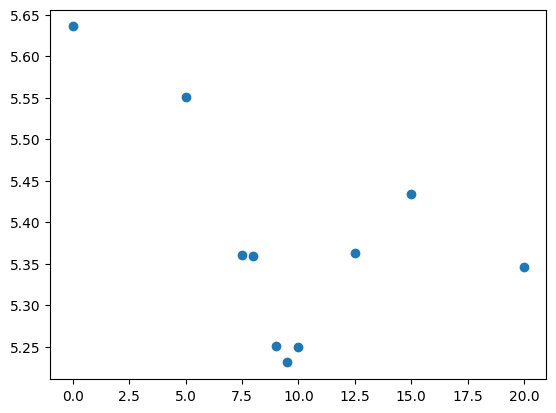

In [102]:
zStagePos = [20,15,10,5,0,12.5,7.5,8,9,9.5]
shifts = [5.346,5.434,5.250,5.551,5.636,5.363,5.360,5.359,5.251,5.231]
plt.scatter(zStagePos,shifts)

In [136]:
result = linregress(zStagePos,shifts)
-result.intercept/result.slope

np.float64(130.83265735316184)

np.float64(130.83265735316184)

In [ ]:
fig,ax = plt.subplots(nrows=1,figsize=[6,6])

for file,maskVal in zip(resultFiles,[21,5]):

    result = np.load(os.path.join(data_dir,file))
    useResult = result[result['stage_pos']!=maskVal]

    if file[0]=="x":
        ax.hist(useResult["y"]-useResult["y"][0],histtype='step',label="Y Position",bins=np.arange(-4,5,step=0.5))
    elif file[0]=="y":
        ax.hist(useResult["x"]-useResult["x"][0],histtype='step',label="X Position",bins=np.arange(-4,5,step=0.5))
ax.legend()
ax.set_ylabel("Counts / bin")
ax.set_xlabel("Pixel offset (rescaled to zero)")

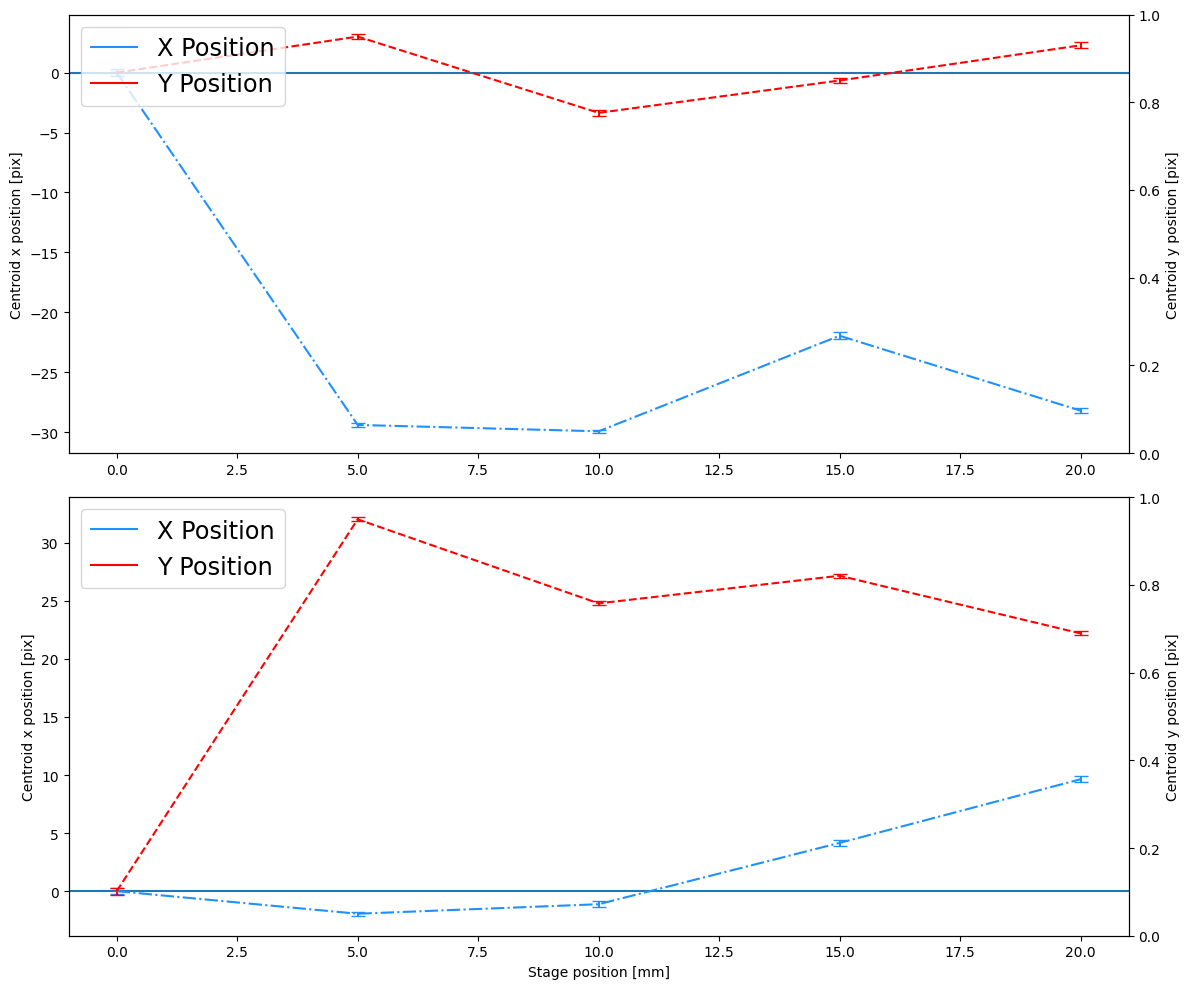

In [16]:
fig,axs = plt.subplots(nrows=2,figsize=[12,10])

for file,ax in zip(resultFiles,axs.flatten(),):

    result = np.load(os.path.join(data_dir,file))
    
    l1 = ax.errorbar(result['stage_pos'],np.diff(result['x']-result['x'][0],prepend=0),yerr=result['x_std'],color='dodgerblue',ls='-.',label='X Position',
                    capsize=5)
    ax.set_ylabel("Centroid x position [pix]")
    ax2 = ax.twinx()
    l2 = ax.errorbar(result['stage_pos'],np.diff(result['y']-result['y'][0],prepend=0),yerr=result['y_std'],color='red',ls='--',label='Y Position',
                     capsize=5)
    ax2.set_ylabel("Centroid y position [pix]")
    ax.legend([l1[2],l2[2]],["X Position","Y Position"],fontsize='xx-large',loc=2)
    ax.axhline(0)
    #ax.set_ylim(-10,10)
ax.set_xlabel("Stage position [mm]")
fig.tight_layout()
fig.savefig(os.path.join(outDir,"xyScanResult_diff.jpg"),dpi=300)